## Credit Card Fraud Detection 

### Objective
Predict whether a transaction is fraudlent based on various features of the transaction . This is a binary classification problem where the target variable is Fraud , indicating whether a transaction is fraudlent (1) or legitimate(0)

# Data Dictionary

1. TransactionID: Unique identifier for each transaction (integer).
2. Transaction Amount: Amount of the transaction in USD (float).
3. TransactionTime: Time of the transaction in hours since the first transaction (float).
4. MerchantCategory: Category of the merchant (categorical: 'Retail', 'Online', 'Restaurant', 'Travel').
5. CustomerAge: Age of the customer making the transaction (integer, ranging from 18 to 80).
6. CustomerGender: Gender of the customer (categorical: 'Male', 'Female').
7. CustomerIncome: Annual income of the customer in USD (integer, ranging from 20,000 to 200,000).
8. TransactionLocation: Location where the transaction took place (categorical: 'Urban', 'Suburban', 'Rural').
9. Previous Fraud Count: Number of fraudulent transactions by the customer in the past 6 months (integer, ranging from 0 to 5).
10. Fraud: Target variable indicating whether the transaction is fraudlent(1) or not(0) binary

# Building a model using Logistic Regression Algorithm

In [1]:
# Import necessary libraries 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [2]:
# Load the dataset
df = pd.read_excel('credit_card_data.xlsx')
df.head()

,TransactionID,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount,Fraud
0,1522,147.32,8344.23,Online,72,Female,101000,Urban,0,0
1,1738,876.78,8434.26,Online,26,Female,146000,Suburban,0,1
2,1741,297.97,7170.58,Restaurant,30,Female,151000,Suburban,0,1
3,1661,50.74,1160.25,Travel,29,Male,58000,Suburban,0,1
4,1412,104.70,2814.35,Online,79,Female,162000,Suburban,0,1


### Essential Exploratory Data Analysis

In [3]:
# summary statistics

df.describe()

,TransactionID,TransactionAmount,TransactionTime,CustomerAge,CustomerIncome,PreviousFraudCount,Fraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,178.583030,4320.824270,48.769000,109943.000000,0.905000,0.650000
std,288.819436,295.125484,2576.854599,18.233488,52026.017121,1.336324,0.477208
min,1001.000000,5.000000,0.460000,18.000000,20000.000000,0.000000,0.000000
25%,1250.750000,40.040000,1933.695000,33.000000,64000.000000,0.000000,0.000000
50%,1500.500000,86.405000,4329.820000,48.000000,111000.000000,0.000000,1.000000
75%,1750.250000,193.270000,6551.540000,65.000000,155000.000000,1.000000,1.000000
max,2000.000000,3364.320000,8751.040000,80.000000,200000.000000,5.000000,1.000000


In [4]:
# check for missing values
df.isnull().sum()

TransactionID          0
TransactionAmount      0
TransactionTime        0
MerchantCategory       0
CustomerAge            0
CustomerGender         0
CustomerIncome         0
TransactionLocation    0
PreviousFraudCount     0
Fraud                  0
dtype: int64

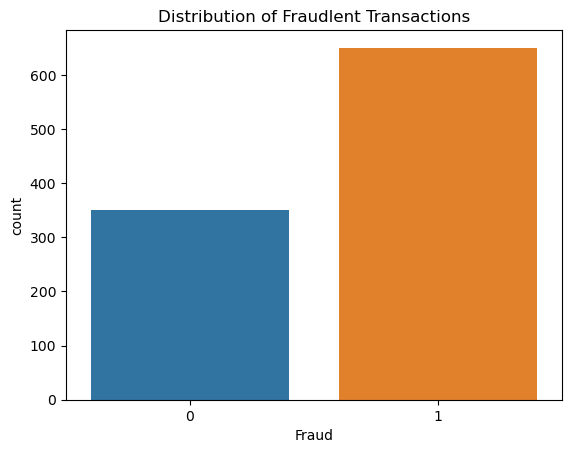

In [5]:
# Distibution of target variable

sns.countplot(x ='Fraud' , data = df)
plt.title('Distribution of Fraudlent Transactions')
plt.show()

C:\Users\jainv\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


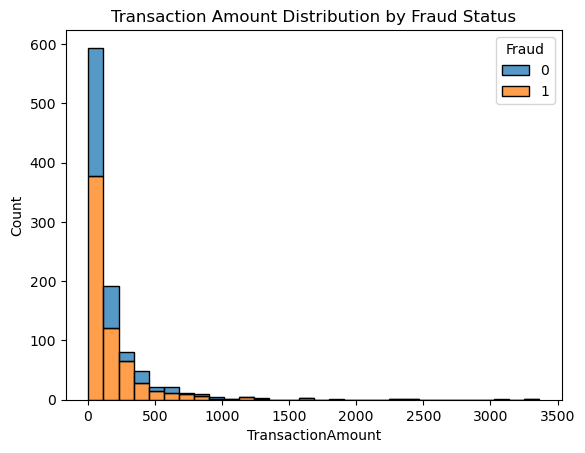

In [6]:
# Disribution of transaction amount by Fraud status

sns.histplot(data = df , x = 'TransactionAmount', hue = 'Fraud' , multiple = 'stack', bins = 30)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.show()

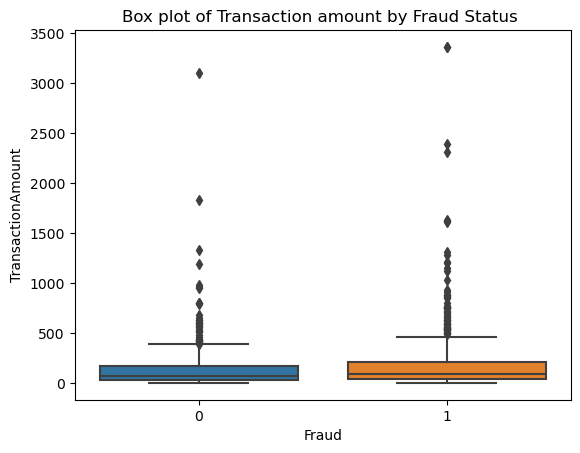

In [7]:
# Box plot for Transaction Amount by Fraud status 
sns.boxplot(x = 'Fraud' , y = 'TransactionAmount' , data = df)
plt.title('Box plot of Transaction amount by Fraud Status ')
plt.show()

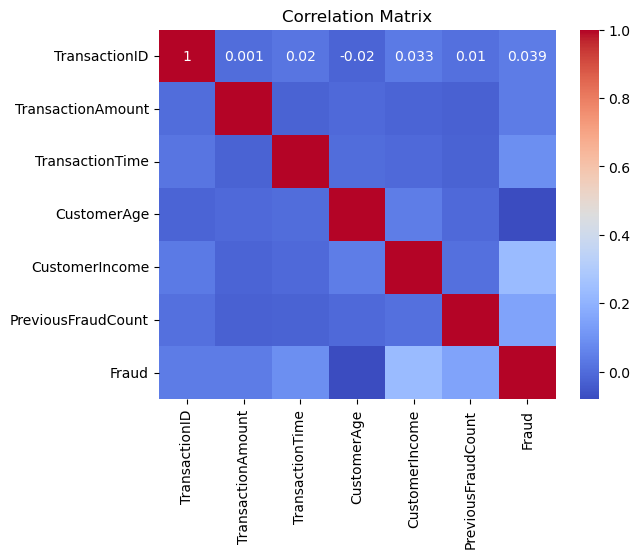

In [8]:
# correlation Matrix 

num_cols = list()

for column in df.columns:
    if df[column].dtype != object:
        num_cols.append(column)
        

correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot = True , cmap = 'coolwarm')
plt.title('Correlation Matrix')

plt.show()
        

### Data Preprocessing 

In [9]:
# Encode categorical variables
label_encoders = {}
for column in ['MerchantCategory', 'CustomerGender', 'TransactionLocation']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

#Features and target
X = df.drop(['TransactionID', 'Fraud'], axis = 1)
y = df['Fraud']

In [10]:
X.head()

,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount
0,147.32,8344.23,0,72,0,101000,2,0
1,876.78,8434.26,0,26,0,146000,1,0
2,297.97,7170.58,1,30,0,151000,1,0
3,50.74,1160.25,3,29,1,58000,1,0
4,104.70,2814.35,0,79,0,162000,1,0


In [11]:
# Split data into training and testing sets
X_train , X_test , y_train , y_test = train_test_split(X, y  , test_size = 0.3 , random_state = 0)

In [12]:
# Feature scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train , y_train)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test , logreg_pred)

In [14]:
# Display accuracy and performace metrices

print(f"Logistic Regression Accuracy : {logreg_accuracy*100: .2f}")
print('\nLogistic Regression Classification report: ')
print(classification_report(y_test, logreg_pred))


Logistic Regression Accuracy :  66.67

Logistic Regression Classification report: 
              precision    recall  f1-score   support

           0       0.53      0.29      0.38       103
           1       0.70      0.86      0.77       197

    accuracy                           0.67       300
   macro avg       0.61      0.58      0.57       300
weighted avg       0.64      0.67      0.64       300



## Building a model using KNN Algorithm 

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# K - Nearest Neighbours
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test , knn_pred)

In [17]:
# Display accuracy and performace metrices

print(f"K- Nearest Neighbours Accuracy : {knn_accuracy*100: .2f}")
print('\nK- Nearest Neighbours Classification report: ')
print(classification_report(y_test, knn_pred))

K- Nearest Neighbours Accuracy :  63.67

K- Nearest Neighbours Classification report: 
              precision    recall  f1-score   support

           0       0.47      0.41      0.44       103
           1       0.71      0.76      0.73       197

    accuracy                           0.64       300
   macro avg       0.59      0.58      0.58       300
weighted avg       0.63      0.64      0.63       300



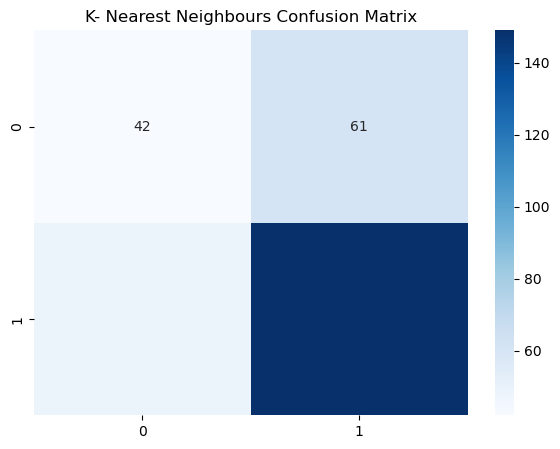

In [18]:
# confusion Matrix 
plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot = True, fmt= 'd', cmap = 'Blues')
plt.title('K- Nearest Neighbours Confusion Matrix')
plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
#Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test , decision_tree_pred)

In [21]:
# Display accuracy and performace metrices

print(f"Decisiosn Tree Accuracy : {decision_tree_accuracy*100: .2f}")
print('\nDecision Tree Classification report: ')
print(classification_report(y_test, decision_tree_pred))

Decisiosn Tree Accuracy :  57.33

Decision Tree Classification report: 
              precision    recall  f1-score   support

           0       0.39      0.43      0.41       103
           1       0.68      0.65      0.67       197

    accuracy                           0.57       300
   macro avg       0.54      0.54      0.54       300
weighted avg       0.58      0.57      0.58       300



In [22]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strat

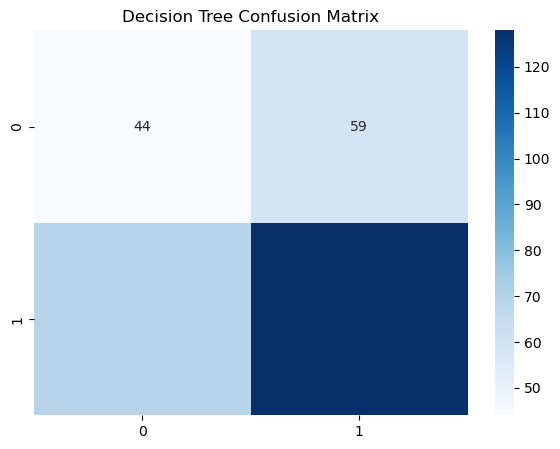

In [23]:
# COnfusion Matrix 
plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test, decision_tree_pred), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

## Building a model using Support Vector Machine Algorithm 

In [24]:
from sklearn.svm import SVC
# svm - support vector machine sub module
# support vector classifier

In [25]:
# Support Vector Machine
# svm - object name here 
svm = SVC()
svm.fit(X_train , y_train)
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

In [26]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)
 |  
 |  C-Support Vector Classification.
 |  
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |  
 |  The multiclass support is handled according to a one-vs-one scheme.
 |  
 |  For details on the precise mathematical formulation of the provided
 |  kernel functions and how `g

In [27]:
# Display accuracy and performace metrices

print(f"Support Vector Machine Accuracy : {svm_accuracy*100: .2f}")
print('\nSupport Vector Machine Classification report: ')
print(classification_report(y_test, svm_pred))

Support Vector Machine Accuracy :  67.00

Support Vector Machine Classification report: 
              precision    recall  f1-score   support

           0       0.56      0.18      0.28       103
           1       0.68      0.92      0.79       197

    accuracy                           0.67       300
   macro avg       0.62      0.55      0.53       300
weighted avg       0.64      0.67      0.61       300



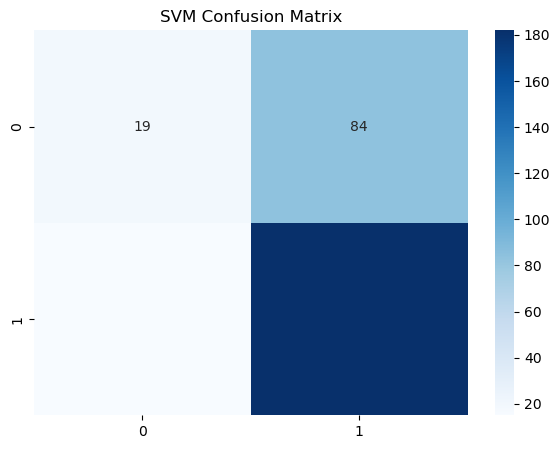

In [28]:
# COnfusion Matrix 
plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('SVM Confusion Matrix')
plt.show()

## Model Comparison

In [29]:
# summary of accuracies

model_accuracies = {
    'Logistic Regression': logreg_accuracy,
    'K-Nearest neighbours': knn_accuracy,
    'Decision Tree': decision_tree_accuracy,
    'Support Vector Machine': svm_accuracy
}

In [30]:
# Display accuracies

for model,accuracy in model_accuracies.items():
    print(f'{model} Accuracy : {accuracy*100:.2f}%')

Logistic Regression Accuracy : 66.67%
K-Nearest neighbours Accuracy : 63.67%
Decision Tree Accuracy : 57.33%
Support Vector Machine Accuracy : 67.00%
